# Olist ECサイト リピート購入分析

**目的:** Olistのリピート購入率（約3%）がなぜ低いのかを特定し、優先すべき改善施策を決める。
分析デザインと結論のまとめは [README.md](README.md) を参照。

**データ:** [Brazilian E-Commerce Public Dataset by Olist (Kaggle)](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — 2016〜2018年の約10万注文、9テーブル。
CSVを `data/` フォルダに置いてから実行する。

## Step 0. セットアップ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path
from scipy import stats

# 日本語フォント設定（環境にあるものを使う）
available = {f.name for f in font_manager.fontManager.ttflist}
for f in ['Yu Gothic', 'Meiryo', 'Hiragino Sans', 'Noto Sans CJK JP', 'Noto Serif CJK JP']:
    if f in available:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

DATA = Path('data')

orders = pd.read_csv(DATA / 'olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date'])
customers = pd.read_csv(DATA / 'olist_customers_dataset.csv')
reviews   = pd.read_csv(DATA / 'olist_order_reviews_dataset.csv')
items     = pd.read_csv(DATA / 'olist_order_items_dataset.csv')
products  = pd.read_csv(DATA / 'olist_products_dataset.csv')
cat_tr    = pd.read_csv(DATA / 'product_category_name_translation.csv')
payments  = pd.read_csv(DATA / 'olist_order_payments_dataset.csv')

for name, df_ in [('orders', orders), ('customers', customers), ('reviews', reviews),
                  ('items', items), ('products', products), ('payments', payments)]:
    print(f'{name:10s} {df_.shape}')

orders     (99441, 8)
customers  (99441, 5)
reviews    (100000, 7)
items      (112650, 7)
products   (32951, 9)
payments   (103886, 5)


## Step 1. データ理解

各テーブルの行数・期間・欠損を確認する。ポイント:

- `orders` と `customers` は同じ行数（99,441）→ `customer_id` は**注文ごとに発行される**ID。人を数えるときは `customer_unique_id` を使う（有名な落とし穴）
- 配達完了 (`delivered`) が96,478件で全体の97%。分析は delivered に絞る
- `order_delivered_customer_date` の欠損（約3,000件）は未配達・キャンセル分

In [2]:
print('期間:', orders.order_purchase_timestamp.min(), '→', orders.order_purchase_timestamp.max())
print()
print(orders.order_status.value_counts())
print()
print('ordersの欠損:')
print(orders.isna().sum())

期間: 2016-09-04 21:15:19 → 2018-10-17 17:30:18

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

ordersの欠損:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


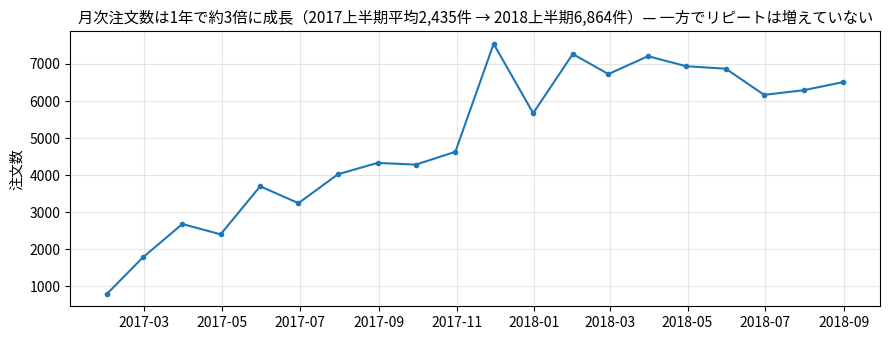

In [3]:
# 月次注文数の推移（データの全体像をつかむ）
monthly = orders.set_index('order_purchase_timestamp').resample('ME')['order_id'].count()
monthly = monthly.loc['2017-01':'2018-08']  # 端の不完全な月は除外

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(monthly.index, monthly.values, marker='o', ms=3)
ax.set_title('月次注文数は1年で約3倍に成長（2017上半期平均2,435件 → 2018上半期6,864件）— 一方でリピートは増えていない', fontsize=11)
ax.set_ylabel('注文数')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 2. リピート率の算出

`customer_unique_id` 単位で注文回数を数え、2回以上購入した顧客の割合を出す。
これが本分析の出発点になる数字。

In [4]:
df = orders.merge(customers, on='customer_id')
delivered = df[df.order_status == 'delivered'].copy()

n_orders = delivered.groupby('customer_unique_id')['order_id'].nunique()
repeat_rate = (n_orders >= 2).mean()

print(f'顧客数（delivered）: {len(n_orders):,}')
print(f'リピート率: {repeat_rate:.2%}')
print()
print('注文回数の分布:')
print(n_orders.value_counts().sort_index().head(6))

# 客単価（施策のインパクト試算で使う）
order_value = payments.groupby('order_id')['payment_value'].sum()
print(f'\n平均注文額: {order_value.mean():.0f} BRL / 中央値: {order_value.median():.0f} BRL')
print(f'総売上（データ全体）: {order_value.sum()/1e6:.1f}M BRL')

顧客数（delivered）: 93,358
リピート率: 3.00%

注文回数の分布:
order_id
1    90557
2     2573
3      181
4       28
5        9
6        5
Name: count, dtype: int64

平均注文額: 161 BRL / 中央値: 105 BRL
総売上（データ全体）: 16.0M BRL


**→ リピート率はわずか3.0%。** 93,358人のうち2回以上買ったのは約2,800人しかいない。
新規獲得で売上は成長しているが、顧客はほぼ全員「一見さん」で終わっている。

## Step 3. 仮説1の検証: 配送遅延 → レビュー低下 → 再購入しない？

- 遅延日数 = 実際の配達日 − 配達予定日
- 「早着 / 期日通り / 遅延1-7日 / 遅延8日以上」の4グループでレビュースコアを比較
- さらに、**初回注文の**レビュー・遅延がその後の再購入に影響したかを確認する

In [5]:
d = delivered.dropna(subset=['order_delivered_customer_date']).copy()
d['delay_days'] = (d.order_delivered_customer_date - d.order_estimated_delivery_date).dt.days
d['delivery_days'] = (d.order_delivered_customer_date - d.order_purchase_timestamp).dt.days
d['delay_group'] = pd.cut(d.delay_days, bins=[-1000, -1, 0, 7, 1000],
                          labels=['早着', '期日通り', '遅延1-7日', '遅延8日以上'])

# レビューは注文ごとに1件に絞る（重複は低い方を採用 = 保守的に）
rev = reviews.sort_values('review_score').drop_duplicates('order_id')
d = d.merge(rev[['order_id', 'review_score']], on='order_id', how='left')

print(f'配達完了注文: {len(d):,}')
print(f'遅延率: {(d.delay_days > 0).mean():.1%} ({(d.delay_days > 0).sum():,}件)')
print(f'平均配達日数: {d.delivery_days.mean():.1f}日（中央値 {d.delivery_days.median():.0f}日）')

g = d.groupby('delay_group', observed=True).agg(
    件数=('order_id', 'size'),
    平均レビュー=('review_score', 'mean'),
    星1の割合=('review_score', lambda s: (s == 1).mean()))
g.round(3)

配達完了注文: 96,470
遅延率: 6.8% (6,534件)
平均配達日数: 12.1日（中央値 10日）


,件数,平均レビュー,星1の割合
delay_group,,,
早着,88644,4.282,0.068
期日通り,1292,4.006,0.092
遅延1-7日,3672,2.695,0.419
遅延8日以上,2862,1.690,0.699


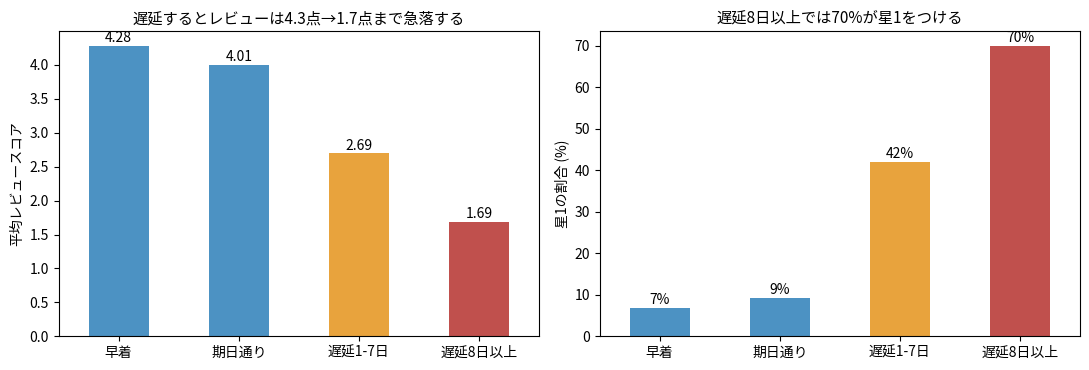

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

g['平均レビュー'].plot.bar(ax=axes[0], color=['#4c92c3', '#4c92c3', '#e8a33d', '#c0504d'], rot=0)
axes[0].set_title('遅延するとレビューは4.3点→1.7点まで急落する', fontsize=11)
axes[0].set_ylabel('平均レビュースコア')
axes[0].set_xlabel('')
for i, v in enumerate(g['平均レビュー']):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center')

(g['星1の割合'] * 100).plot.bar(ax=axes[1], color=['#4c92c3', '#4c92c3', '#e8a33d', '#c0504d'], rot=0)
axes[1].set_title('遅延8日以上では70%が星1をつける', fontsize=11)
axes[1].set_ylabel('星1の割合 (%)')
axes[1].set_xlabel('')
for i, v in enumerate(g['星1の割合'] * 100):
    axes[1].text(i, v + 1, f'{v:.0f}%', ha='center')

plt.tight_layout()
plt.show()

遅延→レビュー低下は**きれいに確認できた**。では「レビューが低い顧客は再購入しない」も成り立つか？
初回注文のレビュースコア別に、その顧客がその後もう一度買った割合を見る。

                 件数    再購入率
review_score               
1              9432  0.0296
2              2909  0.0303
3              7758  0.0300
4             18409  0.0277
5             54842  0.0308


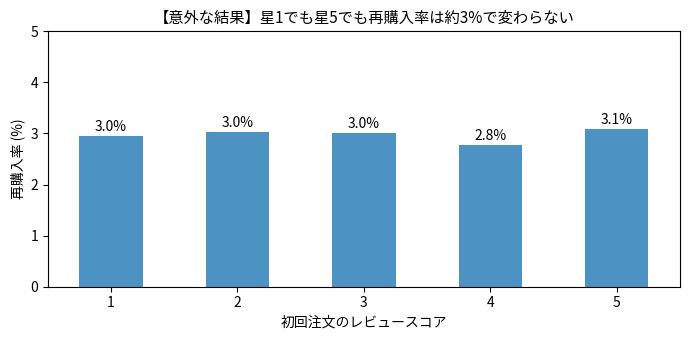

In [7]:
# 顧客ごとの初回注文を特定し、その後再購入したかを判定
first = d.sort_values('order_purchase_timestamp').drop_duplicates('customer_unique_id', keep='first')
first = first.merge(n_orders.rename('n_orders'), on='customer_unique_id')
first['repurchased'] = first.n_orders >= 2

rr = (first.dropna(subset=['review_score'])
      .groupby('review_score')
      .agg(件数=('order_id', 'size'), 再購入率=('repurchased', 'mean')))
print(rr.round(4))

fig, ax = plt.subplots(figsize=(7, 3.5))
(rr['再購入率'] * 100).plot.bar(ax=ax, color='#4c92c3', rot=0)
ax.set_title('【意外な結果】星1でも星5でも再購入率は約3%で変わらない', fontsize=11)
ax.set_ylabel('再購入率 (%)')
ax.set_xlabel('初回注文のレビュースコア')
ax.set_ylim(0, 5)
for i, v in enumerate(rr['再購入率'] * 100):
    ax.text(i, v + 0.1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

In [8]:
# 統計的に確認（カイ二乗検定）
lo = first[first.review_score <= 2]
hi = first[first.review_score >= 4]
tab = [[lo.repurchased.sum(), (~lo.repurchased).sum()],
       [hi.repurchased.sum(), (~hi.repurchased).sum()]]
chi2, p, *_ = stats.chi2_contingency(tab)
print(f'レビュー1-2の再購入率: {lo.repurchased.mean():.2%} (n={len(lo):,})')
print(f'レビュー4-5の再購入率: {hi.repurchased.mean():.2%} (n={len(hi):,})')
print(f'カイ二乗検定 p値 = {p:.3f} → 有意差なし')
print()

late = first[first.delay_days > 0]
ontime = first[first.delay_days <= 0]
tab2 = [[late.repurchased.sum(), (~late.repurchased).sum()],
        [ontime.repurchased.sum(), (~ontime.repurchased).sum()]]
chi2b, pb, *_ = stats.chi2_contingency(tab2)
print(f'初回が遅延した顧客の再購入率: {late.repurchased.mean():.2%} (n={len(late):,})')
print(f'初回が期日内だった顧客     : {ontime.repurchased.mean():.2%} (n={len(ontime):,})')
print(f'カイ二乗検定 p値 = {pb:.3f} → 有意差はあるが差は0.6ポイントと小さい')

レビュー1-2の再購入率: 2.97% (n=12,341)
レビュー4-5の再購入率: 3.00% (n=73,251)
カイ二乗検定 p値 = 0.875 → 有意差なし

初回が遅延した顧客の再購入率: 2.47% (n=6,352)
初回が期日内だった顧客     : 3.04% (n=86,998)
カイ二乗検定 p値 = 0.012 → 有意差はあるが差は0.6ポイントと小さい


### 仮説1の結論

- 遅延 → レビュー低下: **成立**（4.28点 → 1.69点、星1率 7% → 70%）
- レビュー低下 → 再購入しない: **不成立**（星1でも星5でも再購入率は約3%、p=0.87）
- 遅延 → 再購入しない: 統計的には有意（2.5% vs 3.0%、p=0.012）だが、差は0.6ポイントで実務インパクトは小さい

つまり**「配送を改善すればリピートが増える」というよくあるストーリーはOlistでは成り立たない**。
満足した顧客ですら戻ってこない。リピート率3%は個別の不満ではなく構造的な問題。

## Step 4. 仮説2の検証: 商品カテゴリでリピート率は違うか？

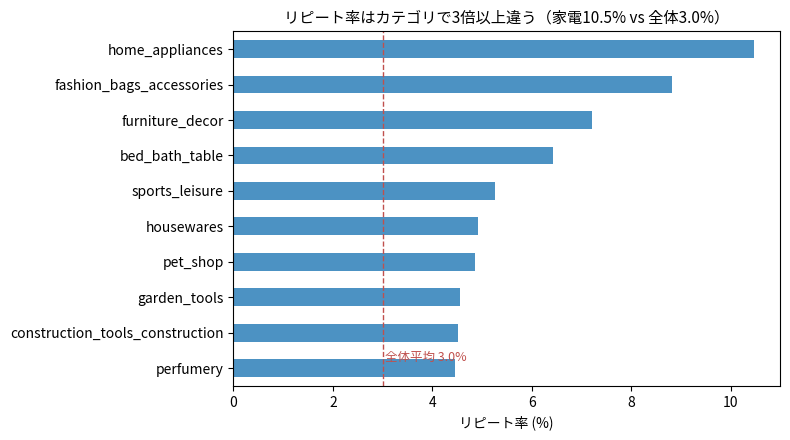

下位5カテゴリ:
                                顧客数  リピート率
product_category_name_english             
auto                           3769    3.3
consoles_games                 1014    3.3
musical_instruments             607    3.1
cool_stuff                     3543    3.1
electronics                    2507    2.9


In [9]:
prod = products.merge(cat_tr, on='product_category_name', how='left')
it = items.merge(prod[['product_id', 'product_category_name_english']], on='product_id', how='left')
oc = (delivered[['order_id', 'customer_unique_id']]
      .merge(it[['order_id', 'product_category_name_english']], on='order_id'))

cust_cat = oc.drop_duplicates(['customer_unique_id', 'product_category_name_english'])
cust_cat = cust_cat.merge(n_orders.rename('n_orders'), on='customer_unique_id')

cat_stats = (cust_cat.groupby('product_category_name_english')
             .agg(顧客数=('customer_unique_id', 'nunique'),
                  リピート率=('n_orders', lambda s: (s >= 2).mean())))
cat_stats = cat_stats[cat_stats.顧客数 >= 500].sort_values('リピート率', ascending=False)

top10 = cat_stats.head(10)
fig, ax = plt.subplots(figsize=(8, 4.5))
(top10['リピート率'] * 100).iloc[::-1].plot.barh(ax=ax, color='#4c92c3')
ax.axvline(3.0, color='#c0504d', ls='--', lw=1)
ax.text(3.05, 0.2, '全体平均 3.0%', color='#c0504d', fontsize=9)
ax.set_title('リピート率はカテゴリで3倍以上違う（家電10.5% vs 全体3.0%）', fontsize=11)
ax.set_xlabel('リピート率 (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('下位5カテゴリ:')
print((cat_stats.tail(5) * [1, 100]).round(1))

**→ 家電（10.5%）、ファッション小物（8.8%）、家具・インテリア（7.2%）、寝具・バス用品（6.4%）は
平均の2〜3.5倍リピートする。** 一方、電子機器・ゲーム機などの耐久財は3%未満。
「どこで買うか」より「何を買うか」がリピートを決めている — 施策のターゲットはここ。

## Step 5. RFMセグメンテーション

Recency（最終購入からの日数）・Frequency（購入回数）・Monetary（累計購入額）で顧客を分類する。
注: 97%の顧客がF=1なので、Frequencyは「リピーターか否か」の2値にした（四分位が機能しないため）。

In [10]:
snap = delivered.order_purchase_timestamp.max() + pd.Timedelta(days=1)
dd = delivered.merge(order_value.rename('order_value'), on='order_id')

rfm = dd.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda s: (snap - s.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('order_value', 'sum'))

rfm['R'] = pd.qcut(rfm.recency, 4, labels=[4, 3, 2, 1]).astype(int)
rfm['M'] = pd.qcut(rfm.monetary, 4, labels=[1, 2, 3, 4]).astype(int)
rfm['F'] = np.where(rfm.frequency >= 2, 2, 1)

def segment(r):
    if r.F == 2 and r.R >= 3: return '優良リピーター'
    if r.F == 2:              return '離脱リピーター'
    if r.R >= 3 and r.M >= 3: return '有望な一見客'
    if r.R >= 3:              return '直近の少額客'
    if r.M >= 3:              return '離脱した高額客'
    return '休眠客'

rfm['segment'] = rfm.apply(segment, axis=1)

seg = rfm.groupby('segment').agg(
    顧客数=('recency', 'size'),
    平均購入額=('monetary', 'mean'),
    売上合計=('monetary', 'sum'))
seg['顧客シェア'] = seg.顧客数 / len(rfm)
seg['売上シェア'] = seg.売上合計 / rfm.monetary.sum()
seg.sort_values('売上合計', ascending=False).round(2)

,顧客数,平均購入額,売上合計,顧客シェア,売上シェア
segment,,,,,
有望な一見客,22542,261.25,5889125.07,0.24,0.38
離脱した高額客,21668,264.39,5728871.14,0.23,0.37
休眠客,23590,63.86,1506436.69,0.25,0.10
直近の少額客,22756,63.00,1433671.66,0.24,0.09
優良リピーター,1549,314.74,487527.24,0.02,0.03
離脱リピーター,1252,300.98,376829.97,0.01,0.02


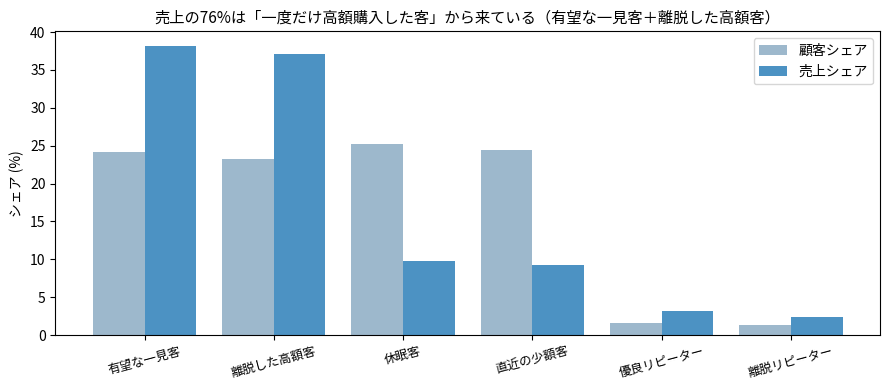

リピーター: 顧客の3.0%、売上の5.6%


In [11]:
order = seg.sort_values('売上シェア', ascending=False).index
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, seg.loc[order, '顧客シェア'] * 100, width=0.4, label='顧客シェア', color='#9db8cc')
ax.bar(x + 0.2, seg.loc[order, '売上シェア'] * 100, width=0.4, label='売上シェア', color='#4c92c3')
ax.set_xticks(x, order, rotation=15, fontsize=9)
ax.set_ylabel('シェア (%)')
ax.set_title('売上の76%は「一度だけ高額購入した客」から来ている（有望な一見客＋離脱した高額客）', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

rep = rfm.frequency >= 2
print(f'リピーター: 顧客の{rep.mean():.1%}、売上の{rfm[rep].monetary.sum() / rfm.monetary.sum():.1%}')

**→ 「有望な一見客」（直近購入・高額・1回のみ）だけで顧客の24%、売上の38%を占める。**
リピーター全体は売上の5.6%しかない。CRM施策を打つならこの「有望な一見客」約22,500人が最優先ターゲット。

## Step 6. コホート分析

初回購入月ごとに顧客をまとめ、その後の月に再購入した割合を追う。
リピートが「時間が経てば起きる」のか「そもそも起きない」のかを確認する。

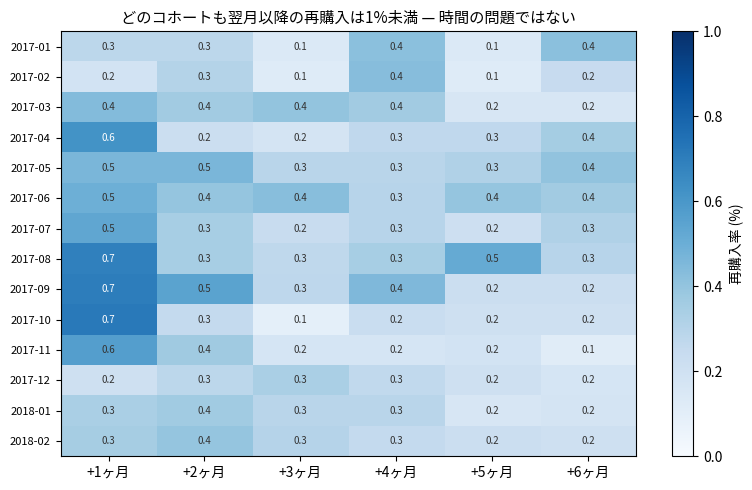

In [12]:
dd2 = delivered.copy()
dd2['month'] = dd2.order_purchase_timestamp.dt.to_period('M')
first_month = dd2.groupby('customer_unique_id')['month'].min().rename('cohort')
dd2 = dd2.merge(first_month, on='customer_unique_id')
dd2['offset'] = (dd2.month - dd2.cohort).apply(lambda x: x.n)

cohort_size = dd2[dd2.offset == 0].groupby('cohort')['customer_unique_id'].nunique()
ret = dd2[dd2.offset > 0].pivot_table(index='cohort', columns='offset',
                                      values='customer_unique_id', aggfunc='nunique')
retention = ret.div(cohort_size, axis=0)

sel = retention.loc['2017-01':'2018-02', list(range(1, 7))] * 100

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(sel.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(6), [f'+{i}ヶ月' for i in range(1, 7)])
ax.set_yticks(range(len(sel)), [str(i) for i in sel.index], fontsize=8)
ax.set_title('どのコホートも翌月以降の再購入は1%未満 — 時間の問題ではない', fontsize=11)
for i in range(sel.shape[0]):
    for j in range(sel.shape[1]):
        v = sel.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7,
                    color='white' if v > 0.6 else '#333')
fig.colorbar(im, label='再購入率 (%)')
plt.tight_layout()
plt.show()

**→ どの月に初めて買った顧客も、翌月に再購入するのは0.3〜0.7%程度。**
成長期・繁忙期に関係なく一貫して低い。リピートの少なさはOlistのビジネスモデル
（多数の中小セラーのマーケットプレイスで、顧客は「店」ではなく「商品」を単発で買う）に根ざしている。

## Step 7. まとめと施策提案

In [13]:
# 施策のインパクト試算
aov = order_value.mean()
n_cust = len(n_orders)
target = rfm[rfm.segment == '有望な一見客']

print('--- 試算の前提 ---')
print(f'平均注文額 {aov:.0f} BRL / 顧客数 {n_cust:,} / 総売上 {order_value.sum()/1e6:.1f}M BRL')
print()
print('施策A: 遅延削減（遅延を半減させた場合の再購入増）')
n_late = (first.delay_days > 0).sum()
gap = ontime.repurchased.mean() - late.repurchased.mean()
print(f'  遅延初回注文 {n_late:,}件 × 再購入率ギャップ {gap:.2%} ÷ 2 × {aov:.0f} BRL ≈ {n_late * gap / 2 * aov:,.0f} BRL')
print('  → 再購入への直接効果はごく小さい（ただしレビュー・ブランド保護の価値は別途大きい）')
print()
print('施策B: 「有望な一見客」向けCRM（リピート率の高いカテゴリ購入者に購入後クーポン）')
print(f'  ターゲット {len(target):,}人。再購入率を+3ポイント改善できた場合:')
print(f'  {len(target):,} × 3% × {aov:.0f} BRL ≈ {len(target) * 0.03 * aov:,.0f} BRL（総売上の約{len(target) * 0.03 * aov / order_value.sum():.1%}）')
print()
print('参考: 全体のリピート率が3%→4%になった場合')
print(f'  {n_cust:,} × 1% × {aov:.0f} BRL ≈ {n_cust * 0.01 * aov:,.0f} BRL')

--- 試算の前提 ---
平均注文額 161 BRL / 顧客数 93,358 / 総売上 16.0M BRL

施策A: 遅延削減（遅延を半減させた場合の再購入増）
  遅延初回注文 6,352件 × 再購入率ギャップ 0.57% ÷ 2 × 161 BRL ≈ 2,902 BRL
  → 再購入への直接効果はごく小さい（ただしレビュー・ブランド保護の価値は別途大きい）

施策B: 「有望な一見客」向けCRM（リピート率の高いカテゴリ購入者に購入後クーポン）
  ターゲット 22,542人。再購入率を+3ポイント改善できた場合:
  22,542 × 3% × 161 BRL ≈ 108,871 BRL（総売上の約0.7%）

参考: 全体のリピート率が3%→4%になった場合
  93,358 × 1% × 161 BRL ≈ 150,297 BRL


### 結論

**主な発見**

1. **リピート率は3.0%**（93,358人中、2回以上購入は約2,800人）。売上は新規獲得だけで成長している
2. **配送遅延はレビューを壊すが（4.28→1.69点）、リピートは壊さない**。星1でも星5でも再購入率は約3%（p=0.87）。「配送改善→リピート増」の仮説は不成立
3. **リピートを決めるのはカテゴリ**。家電10.5%・ファッション小物8.8% vs 電子機器2.9%。また売上の76%は「一度だけ高額購入した客」に集中

**施策提案（優先順）**

1. **「有望な一見客」約22,500人（売上シェア38%）への購入後CRM** — 特にリピート率上位カテゴリ（家電・ファッション小物・家具・寝具）の購入者に、次回クーポンと関連商品レコメンドを配信。+3ptで約11万BRL/年の増収余地
2. **遅延削減はレビュー・ブランド保護として実施** — 星1レビューの32%は遅延注文。リピート目的ではなくマーケットプレイスの信頼維持として投資判断すべき
3. **リピートを狙わないなら一見客のLTV最大化** — クロスセル・バスケット単価向上の方がOlistの構造には合う

**分析の限界**

- データは2018年10月で終わっており、後半に初回購入した顧客は再購入の観察期間が短い（リピート率をやや過小評価）
- レビューと再購入の関係は相関ベースの検証であり、厳密な因果推論（例: 傾向スコアマッチング）は今後の課題